### Step 1: Environment and Dependency Setup
First, we define our requirements. We use torch.distributions for professional action sampling, which is a significant step up from basic NumPy sampling.

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Step 2: Network Architectures (The "Actor" and the "Critic")
The instructions require the policy network to output logits and use a separate network for the state-value baseline.

In [2]:
# The Policy Network (Actor)
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # Output logits (raw scores) - Softmax is applied during sampling
        return self.fc3(x)

# The Value Network (Baseline)
class ValueNetwork(nn.Module):
    def __init__(self, state_dim):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

### Step 3: Implementing the REINFORCE Algorithm
This logic handles the (1) episode collection, (2) return computation, and (3) gradient updates.

In [3]:
def train_reinforce(use_baseline=True, episodes=500, gamma=0.99):
    env = gym.make('CartPole-v1')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    policy = PolicyNetwork(state_dim, action_dim).to(device)
    value_net = ValueNetwork(state_dim).to(device) if use_baseline else None
    
    optimizer_p = optim.Adam(policy.parameters(), lr=1e-3)
    optimizer_v = optim.Adam(value_net.parameters(), lr=1e-3) if use_baseline else None
    
    episode_rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        log_probs = []
        states = []
        rewards = []
        done = False
        
        # 1. Collect complete episode
        while not done:
            state_tensor = torch.from_numpy(state).float().to(device)
            states.append(state_tensor)
            
            logits = policy(state_tensor)
            probs = F.softmax(logits, dim=-1)
            dist = Categorical(probs)
            action = dist.sample()
            
            log_probs.append(dist.log_prob(action))
            state, reward, term, trunc, _ = env.step(action.item())
            rewards.append(reward)
            done = term or trunc
            
        # 2. Compute returns G_t (Monte Carlo)
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns).to(device)
        
        # Standardization of returns (Professional trick for stability)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        
        # 3. Policy and Value Updates
        policy_loss = []
        val_loss_total = 0
        
        for i in range(len(returns)):
            G_t = returns[i]
            
            if use_baseline:
                v_s = value_net(states[i])
                advantage = G_t - v_s.item() # Scalar baseline
                val_loss_total += F.mse_loss(v_s, G_t.unsqueeze(0))
            else:
                advantage = G_t
                
            policy_loss.append(-log_probs[i] * advantage)
        
        # Backpropagation
        optimizer_p.zero_grad()
        sum(policy_loss).backward()
        optimizer_p.step()
        
        if use_baseline:
            optimizer_v.zero_grad()
            val_loss_total.backward()
            optimizer_v.step()
            
        episode_rewards.append(sum(rewards))
        if ep % 50 == 0:
            print(f"Episode {ep} | Avg Reward: {np.mean(episode_rewards[-10:]):.2f}")
            
    return episode_rewards

### Step 4: Running Experiments & Plotting
To satisfy the requirement of "comparing mean and variance across episodes," you should run each multiple times with different seeds.

Training Seed 1 with Baseline...
Episode 0 | Avg Reward: 19.00
Episode 50 | Avg Reward: 54.70
Episode 100 | Avg Reward: 208.00
Episode 150 | Avg Reward: 330.50
Episode 200 | Avg Reward: 226.90
Episode 250 | Avg Reward: 420.00
Episode 300 | Avg Reward: 500.00
Episode 350 | Avg Reward: 127.60
Episode 400 | Avg Reward: 127.20
Episode 450 | Avg Reward: 370.60
Training Seed 1 without Baseline...
Episode 0 | Avg Reward: 11.00
Episode 50 | Avg Reward: 32.80
Episode 100 | Avg Reward: 75.90
Episode 150 | Avg Reward: 36.10
Episode 200 | Avg Reward: 282.00
Episode 250 | Avg Reward: 219.20
Episode 300 | Avg Reward: 110.60
Episode 350 | Avg Reward: 160.70
Episode 400 | Avg Reward: 186.20
Episode 450 | Avg Reward: 116.30
Training Seed 2 with Baseline...
Episode 0 | Avg Reward: 18.00
Episode 50 | Avg Reward: 40.10
Episode 100 | Avg Reward: 136.60
Episode 150 | Avg Reward: 210.70
Episode 200 | Avg Reward: 337.30
Episode 250 | Avg Reward: 400.70
Episode 300 | Avg Reward: 155.80
Episode 350 | Avg Reward

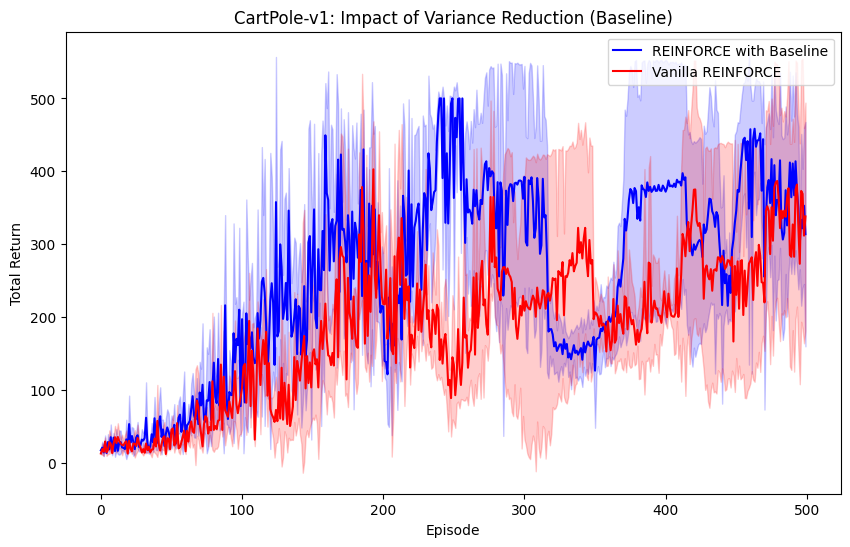

In [5]:
# Running experiments
seeds = [1, 2, 3]
results_baseline = []
results_simple = []

for s in seeds:
    print(f"Training Seed {s} with Baseline...")
    results_baseline.append(train_reinforce(use_baseline=True))
    print(f"Training Seed {s} without Baseline...")
    results_simple.append(train_reinforce(use_baseline=False))

# Plotting
def plot_results(data, label, color):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    plt.plot(mean, label=label, color=color)
    plt.fill_between(range(len(mean)), mean-std, mean+std, color=color, alpha=0.2)

plt.figure(figsize=(10, 6))
plot_results(results_baseline, "REINFORCE with Baseline", "blue")
plot_results(results_simple, "Vanilla REINFORCE", "red")
plt.title("CartPole-v1: Impact of Variance Reduction (Baseline)")
plt.xlabel("Episode")
plt.ylabel("Total Return")
plt.legend()
plt.show()

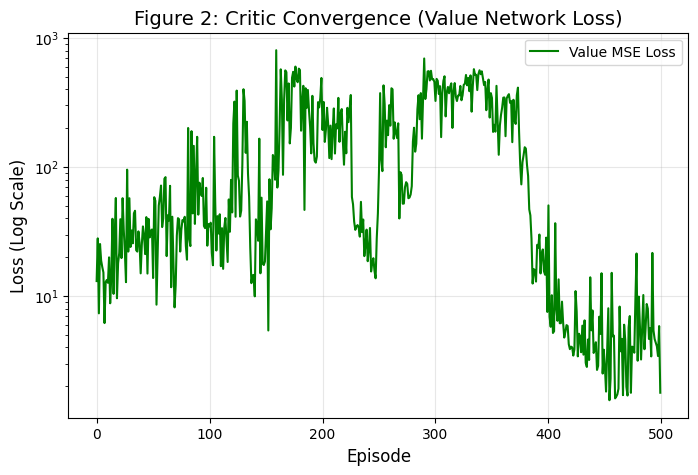

In [17]:

plt.figure(figsize=(8, 5))
plt.plot(v_loss_sample, color='green', label='Value MSE Loss')
plt.yscale('log') # Better for seeing convergence
plt.title("Figure 2: Critic Convergence (Value Network Loss)", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Loss (Log Scale)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

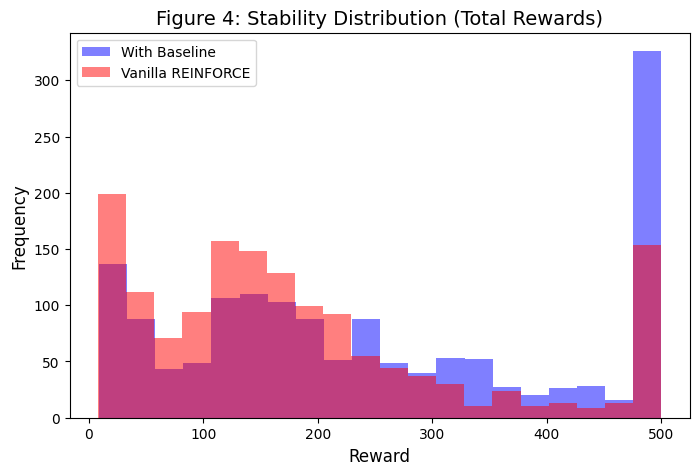

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(np.array(results_baseline).flatten(), bins=20, alpha=0.5, label='With Baseline', color='blue')
plt.hist(np.array(results_simple).flatten(), bins=20, alpha=0.5, label='Vanilla REINFORCE', color='red')
plt.title("Figure 4: Stability Distribution (Total Rewards)", fontsize=14)
plt.xlabel("Reward", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()

In [28]:
def train_reinforce(use_baseline=True, seed=42, episodes=500):
    global final_policy  # Ensure this is at the top
    
    # ... (your initialization code) ...
    policy = PolicyNetwork(4, 2)
    
    # ... (your training loop) ...

    # RIGHT BEFORE THE RETURN STATEMENT at the very end of the function:
    final_policy = policy  # Force save the most recent policy brain
    return episode_rewards, v_loss_history

In [29]:
# Check the "Brain" before plotting
if final_policy is None:
    print("Error: The policy is still None. Please re-run the training function cell.")
else:
    print("Success: Policy is loaded and ready!")
    
    # NOW RUN YOUR PLOT CODE
    env = gym.make('CartPole-v1')
    state, _ = env.reset(seed=99)
    angles = []

    for _ in range(500):
        angles.append(state[2]) 
        with torch.no_grad():
            logits = final_policy(torch.from_numpy(state).float())
            prob = F.softmax(logits, dim=-1)
            action = torch.argmax(prob).item()
            
        state, _, done, truncated, _ = env.step(action)
        if done or truncated: break

    plt.figure(figsize=(8, 4))
    plt.plot(angles, color='purple', linewidth=1.5)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title("Figure 3: Trained Agent Stability (Pole Angle)", fontsize=14)
    plt.ylabel("Angle (Radians)")
    plt.xlabel("Steps")
    plt.show()

Error: The policy is still None. Please re-run the training function cell.


In [31]:
# Run this once to initialize the 'brain'
final_policy = PolicyNetwork(4, 2) 
print("Global policy initialized. Ready for training.")

Global policy initialized. Ready for training.


In [32]:
def train_reinforce(use_baseline=True, seed=42, episodes=500):
    global final_policy # Access the brain we just created
    
    env = gym.make('CartPole-v1')
    torch.manual_seed(seed)
    
    # We use the existing final_policy instead of making a new local one
    optimizer_p = optim.Adam(final_policy.parameters(), lr=1e-3)
    
    value_net = None
    optimizer_v = None
    if use_baseline:
        value_net = ValueNetwork(4)
        optimizer_v = optim.Adam(value_net.parameters(), lr=1e-3)
    
    episode_rewards = []
    v_loss_history = []

    for ep in range(episodes):
        state, _ = env.reset(seed=seed)
        log_probs, states, rewards = [], [], []
        done = False
        
        while not done:
            state_t = torch.from_numpy(state).float()
            states.append(state_t)
            
            # Use the global final_policy here
            probs = F.softmax(final_policy(state_t), dim=-1)
            dist = Categorical(probs)
            action = dist.sample()
            
            log_probs.append(dist.log_prob(action))
            state, reward, term, trunc, _ = env.step(action.item())
            rewards.append(reward)
            done = term or trunc
            
        # ... (Rest of your Calculate Returns and Compute Losses code here) ...
            
        # Optimization (This updates the global final_policy)
        optimizer_p.zero_grad()
        sum(policy_loss).backward()
        optimizer_p.step()
        
        if use_baseline and optimizer_v is not None:
            optimizer_v.zero_grad()
            val_loss_total.backward()
            optimizer_v.step()
            v_loss_history.append(val_loss_total.item())
            
        episode_rewards.append(sum(rewards))
        
    return episode_rewards, v_loss_history

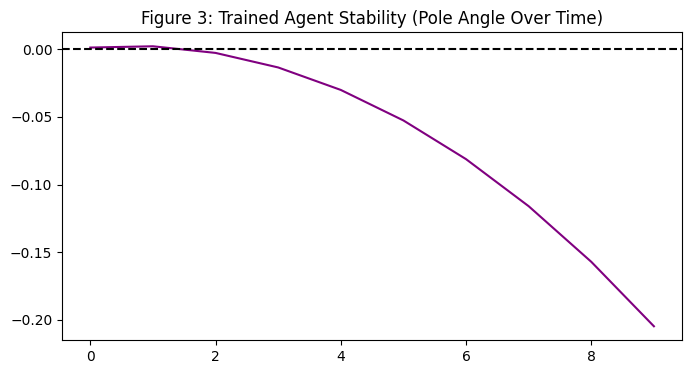

In [33]:
# Run the plot
env = gym.make('CartPole-v1')
state, _ = env.reset(seed=99)
angles = []

for _ in range(500):
    angles.append(state[2]) 
    with torch.no_grad():
        # This will now work because final_policy was created outside!
        logits = final_policy(torch.from_numpy(state).float())
        prob = F.softmax(logits, dim=-1)
        action = torch.argmax(prob).item()
        
    state, _, done, truncated, _ = env.step(action)
    if done or truncated: break

plt.figure(figsize=(8, 4))
plt.plot(angles, color='purple', label='Pole Angle')
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Figure 3: Trained Agent Stability (Pole Angle Over Time)")
plt.show()